In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_colwidth", 200)

print("Environment ready! 🚀")

Environment ready! 🚀


In [2]:
from pathlib import Path

DATA_DIR = Path("../data/raw")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Train exists:", TRAIN_PATH.exists())
print("Test exists :", TEST_PATH.exists())

Train exists: True
Test exists : True


In [18]:
train_sample = pd.read_csv(
    TRAIN_PATH,
    nrows=10000
)

test_sample = pd.read_csv(
    TEST_PATH,
    nrows=5000
)

print(train_sample.columns)
print(train_sample.head())

Index(['class_index', 'review_title', 'review_text'], dtype='str')
   class_index                                            review_title  \
0            2                          Stuning even for the non-gamer   
1            2                   The best soundtrack ever to anything.   
2            2                                                Amazing!   
3            2                                    Excellent Soundtrack   
4            2  Remember, Pull Your Jaw Off The Floor After Hearing it   

                                                                                                                                                                                               review_text  
0  This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the gam...  
1  I'm reading a lot of reviews saying that this is the best 'game soundtrack'

In [19]:
train_sample = train_sample.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

test_sample = test_sample.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

In [20]:
train_sample.head()

,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the gam...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. ...
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant Promise"" an..."
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of...
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical..."


In [21]:
train_sample["label"] = train_sample["label"].map({
    1: 0,
    2: 1
})

test_sample["label"] = test_sample["label"].map({
    1: 0,
    2: 1
})

In [22]:
print(train_sample["label"].value_counts(dropna=False))

label
0    5097
1    4903
Name: count, dtype: int64


In [23]:
train_sample["text"] = (
    train_sample["title"].fillna("") + " " +
    train_sample["text"].fillna("")
).str.strip()

test_sample["text"] = (
    test_sample["title"].fillna("") + " " +
    test_sample["text"].fillna("")
).str.strip()

In [24]:
train_sample[["label", "text"]].head()

,label,text
0,1,Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono ...
1,1,The best soundtrack ever to anything. I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yas...
2,1,"Amazing! This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant Pr..."
3,1,Excellent Soundtrack I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my f...
4,1,"Remember, Pull Your Jaw Off The Floor After Hearing it If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs ..."


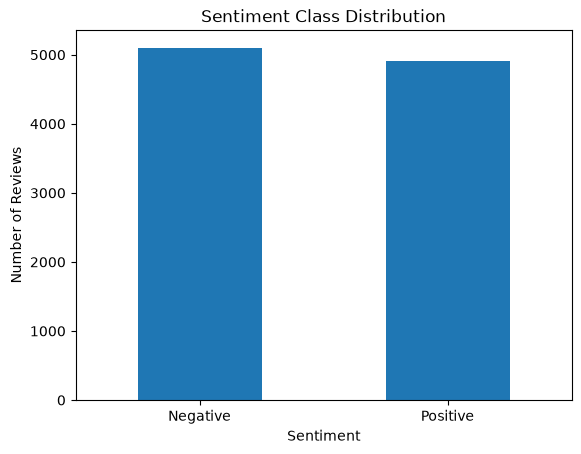

In [25]:
train_sample["label"].value_counts().plot(
    kind="bar",
    title="Sentiment Class Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
    rotation=0
)

plt.show()

In [26]:
# Review length statistics
train_sample["text_length"] = train_sample["text"].str.len()

train_sample["text_length"].describe()

count    10000.000000
mean       437.702600
std        239.243635
min        100.000000
25%        237.000000
50%        390.000000
75%        604.000000
max       1014.000000
Name: text_length, dtype: float64

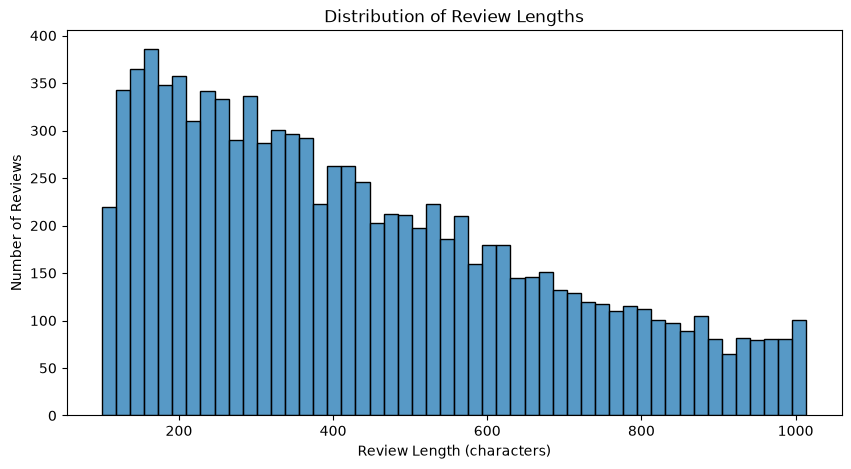

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_sample["text_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")

plt.show()

In [28]:
for i in range(5):
    sentiment = "Positive" if train_sample.iloc[i]["label"] == 1 else "Negative"
    
    print(f"Sentiment: {sentiment}")
    print(f"Review: {train_sample.iloc[i]['text']}")
    print("-" * 100)

Sentiment: Positive
Review: Stuning even for the non-gamer This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
----------------------------------------------------------------------------------------------------
Sentiment: Positive
Review: The best soundtrack ever to anything. I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to b

In [29]:
print("Missing values:")
print(train_sample[["label", "title", "text"]].isnull().sum())

print("\nDuplicate reviews:")
print(train_sample["text"].duplicated().sum())

Missing values:
label    0
title    0
text     0
dtype: int64

Duplicate reviews:
0
